# Which sessions are actually well described by a population-wide anchoring state?

`population_anchoring_agreement.ipynb` showed that PC1 explained variance
of the cell x trial anchoring-label matrix varies a lot across sessions
(6-33%), and by eye, some sessions' PC1-sorted rasters show a genuinely
clean, coherent population-wide switch while others look like independent
per-cell noise with no shared structure. Raw PC1 explained variance alone
can't distinguish these two cases, because **PC1 of pure noise is not
zero** -- with finitely many cells and trials, the first principal
component of a random binary matrix always captures more variance than the
uniform 1/n_cells baseline, and how much more depends on the session's own
cell count and trial count. A session's raw PC1 value is only meaningful
relative to what chance alignment would produce *for a matrix that shape*.

This notebook builds that null directly (per-cell circular-shift
permutation) and tests, session by session, whether the observed PC1
explained variance exceeds it -- separating sessions where "the population
shares an anchoring state" is a statistically supported description from
sessions where it isn't, and producing a concrete `session_validity_summary.csv`
that other notebooks in this collection can use to subset to the sessions
worth trusting for population-level analysis.

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Arial'

ALL_SESSIONS_DIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/all_sessions_rasters'
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'

ANCH_COLOR, NONANCH_COLOR = '#9d5391', '#5f9ea0'
from matplotlib.colors import ListedColormap, BoundaryNorm
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)

N_SHUFFLES = 1000
rng = np.random.default_rng(0)


def pc1_explained_var(M):
    pca = PCA(n_components=1)
    pca.fit(M)
    return pca.explained_variance_ratio_[0]


def circular_shift_null(M, n_shuffles, rng):
    """Null distribution for PC1 explained variance under 'no shared cross-cell
    timing'. Each cell's label sequence is circularly shifted by an
    independent random offset -- this exactly preserves that cell's own
    run-length/autocorrelation structure (a real anchored/non-anchored state
    persists for many trials; a circular shift keeps that intact) while
    destroying any TRIAL-BY-TRIAL ALIGNMENT between cells. A full random
    permutation of each cell's trials would also destroy each cell's own
    real temporal structure, which is not what's being tested here -- the
    question is specifically whether cells' switching happens to line up in
    time more than chance, not whether any single cell's switching pattern
    is unusual on its own."""
    n_cells, n_trials = M.shape
    null_vals = np.empty(n_shuffles)
    for i in range(n_shuffles):
        shifts = rng.integers(0, n_trials, size=n_cells)
        M_shift = np.array([np.roll(M[c], shifts[c]) for c in range(n_cells)])
        null_vals[i] = pc1_explained_var(M_shift)
    return null_vals


print(f'{len(glob.glob(os.path.join(ALL_SESSIONS_DIR, "*_cache.npz")))} cached sessions, '
      f'{N_SHUFFLES} circular-shift shuffles per session')


75 cached sessions, 1000 circular-shift shuffles per session


## The null: circular-shift permutation

For each session, shuffle each cell's label sequence **independently, by a
random circular shift** (not a full random permutation) many times, and
recompute PC1 explained variance each time.

Circular shift, specifically, because it preserves what shouldn't be
tested away: a real anchored state persists for many consecutive trials
(that's a property of one cell's own switching behaviour, already
established and not in question), and a circular shift keeps that
run-length structure completely intact. What it destroys is the **trial-by-
trial alignment between cells** -- shifting cell A by a random 17 trials and
cell B by a random 43 trials will decorrelate any genuine shared switching
time, while each cell's own statistics (how much of the session it spends
anchored, how long its runs are) are exactly preserved. This isolates the
one thing being tested: do cells happen to switch state together more than
their own individual switching behaviour would predict by chance?

1000 shuffles per session; p-value = fraction of shuffles with PC1 >= the
real value (floored at 1/1001 rather than reported as exactly 0).

In [2]:
"""
For every session, test whether its real PC1 explained variance exceeds
what a circular-shift null (same per-cell switching statistics, no
cross-cell timing) would produce by chance. This directly separates
sessions where "the population as a whole shares an anchoring state" is a
statistically supported description from sessions where the observed PC1
value is exactly what you'd expect from each cell switching independently.
"""
import time
t0 = time.time()
rows = []
for cache_path in sorted(glob.glob(os.path.join(ALL_SESSIONS_DIR, '*_cache.npz'))):
    fname = os.path.basename(cache_path)
    m = re.match(r'M(\d+)D(\d+)_cache\.npz', fname)
    mouse, day = int(m.group(1)), int(m.group(2))
    d = np.load(cache_path, allow_pickle=True)
    label_matrix = d['label_matrix']
    M = np.nan_to_num(label_matrix, nan=0.0)
    n_cells, n_trials = M.shape

    real_pc1 = pc1_explained_var(M)
    null_vals = circular_shift_null(M, N_SHUFFLES, rng)
    z = (real_pc1 - null_vals.mean()) / null_vals.std()
    p = max((null_vals >= real_pc1).mean(), 1.0 / (N_SHUFFLES + 1))   # floor at shuffle resolution, not literal 0

    rows.append(dict(mouse=mouse, day=day, n_cells=n_cells, n_trials=n_trials,
                      pc1_var=real_pc1, null_mean=null_vals.mean(), null_std=null_vals.std(),
                      null_95=np.percentile(null_vals, 95), z=z, p=p,
                      excess_over_null95=real_pc1 - np.percentile(null_vals, 95)))

validity_df = pd.DataFrame(rows)

# The empirical p-value above is exact but floored at 1/(N_SHUFFLES+1) ~ 0.001 --
# with 1000 shuffles it simply can't resolve anything smaller, which would make
# the Bonferroni comparison below look like a measurement-resolution artifact
# for any session whose true p is far below that floor (several sessions here
# have z in the hundreds, i.e. real PC1 is hundreds of null-standard-deviations
# above the null mean -- not a borderline case). A parametric normal-
# approximation p-value from the z-score has no such floor and is used for the
# Bonferroni comparison; the empirical p (exact but floor-limited) is kept for
# the uncorrected comparison, where the floor rarely binds.
from scipy.stats import norm
validity_df['p_parametric'] = norm.sf(validity_df['z'])

BONFERRONI_ALPHA = 0.05 / len(validity_df)
validity_df['valid_p05'] = validity_df['p'] < 0.05
validity_df['valid_bonferroni'] = validity_df['p_parametric'] < BONFERRONI_ALPHA

print(f'done in {time.time()-t0:.0f}s for {len(validity_df)} sessions')
print(f'sessions with p<0.05 (uncorrected, empirical): {validity_df.valid_p05.sum()}/{len(validity_df)}')
print(f'sessions with p<{BONFERRONI_ALPHA:.4f} (Bonferroni-corrected for {len(validity_df)} sessions, '
      f'parametric from z to avoid the empirical floor): '
      f'{validity_df.valid_bonferroni.sum()}/{len(validity_df)}')
print()
print('sessions that do NOT clear even the uncorrected p<0.05 bar (candidates to exclude from '
      'population-level subsetting):')
print(validity_df[~validity_df.valid_p05].sort_values('p', ascending=False)[
    ['mouse', 'day', 'n_cells', 'n_trials', 'pc1_var', 'null_95', 'z', 'p']].to_string(index=False))


done in 433s for 75 sessions
sessions with p<0.05 (uncorrected, empirical): 68/75
sessions with p<0.0007 (Bonferroni-corrected for 75 sessions, parametric from z to avoid the empirical floor): 59/75

sessions that do NOT clear even the uncorrected p<0.05 bar (candidates to exclude from population-level subsetting):
 mouse  day  n_cells  n_trials  pc1_var  null_95         z     p
    20   25       37       395 0.093550 0.099974 -0.900562 0.804
    27   21      141       322 0.067467 0.068564  0.263154 0.363
    27   20       97       372 0.061474 0.062344  1.079261 0.141
    20   15       75       335 0.162373 0.162630  1.387561 0.092
    20   24       81       412 0.080949 0.081299  1.377580 0.087
    22   34      243       190 0.064105 0.064285  1.428263 0.082
    22   37      168       226 0.076112 0.076196  1.596830 0.060


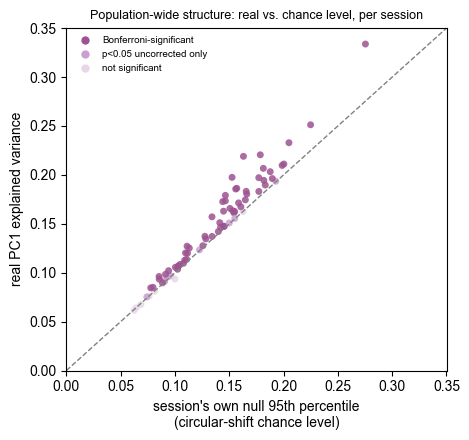

In [3]:
"""Real PC1 explained variance vs. each session's own null 95th-percentile
threshold -- points above the diagonal exceed what chance cross-cell
alignment would produce given that session's own cell count/switching
statistics; points on or below it don't."""
fig, ax = plt.subplots(figsize=(4.8, 4.5))
colors = np.where(validity_df['valid_bonferroni'], ANCH_COLOR,
                   np.where(validity_df['valid_p05'], '#c9a0d1', NONANCH_COLOR))
ax.scatter(validity_df['null_95'], validity_df['pc1_var'], c=colors, s=25, alpha=0.85, edgecolor='none')
lims = [0, max(validity_df['pc1_var'].max(), validity_df['null_95'].max()) * 1.05]
ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1, label='real = null 95th pct.')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("session's own null 95th percentile\n(circular-shift chance level)")
ax.set_ylabel('real PC1 explained variance')
ax.set_title('Population-wide structure: real vs. chance level, per session', fontsize=9)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ANCH_COLOR, markersize=7, label='Bonferroni-significant'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor='#c9a0d1', markersize=7, label='p<0.05 uncorrected only'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor=NONANCH_COLOR, markersize=7, label='not significant')]
ax.legend(handles=handles, fontsize=7, loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'session_validity_real_vs_null95.pdf'), dpi=200, bbox_inches='tight')
plt.show()


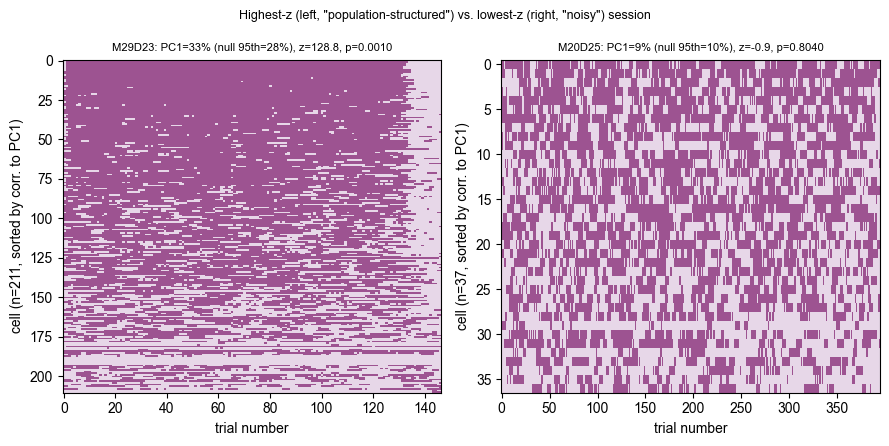

In [4]:
"""
Do the sessions this test calls 'well described by a population-wide
state' actually look that way by eye, and do the 'noisy' sessions actually
look noisy? PC1-sorted rasters for the highest-z and lowest-z sessions,
side by side, using each session's already-cached label matrix and PC1
correlations (Part D of trial_cluster_anchoring.ipynb) -- no recomputation.
"""
best_row = validity_df.loc[validity_df['z'].idxmax()]
worst_row = validity_df.loc[validity_df['z'].idxmin()]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, row in zip(axes, [best_row, worst_row]):
    cache_path = os.path.join(ALL_SESSIONS_DIR, f'M{int(row.mouse)}D{int(row.day)}_cache.npz')
    d = np.load(cache_path, allow_pickle=True)
    label_matrix = d['label_matrix']
    pc1_corrs = d['pc1_corrs']
    order = np.argsort(-pc1_corrs)
    ax.imshow(label_matrix[order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    ax.set_xlabel('trial number')
    ax.set_ylabel(f'cell (n={label_matrix.shape[0]}, sorted by corr. to PC1)')
    ax.set_title(f'M{int(row.mouse)}D{int(row.day)}: PC1={row.pc1_var:.0%} '
                 f'(null 95th={row.null_95:.0%}), z={row.z:.1f}, p={row.p:.4f}', fontsize=8)
fig.suptitle('Highest-z (left, "population-structured") vs. lowest-z (right, "noisy") session', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'session_validity_best_vs_worst_example.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Confound check: is this just tracking session size?

Sessions with more cells or more trials have more statistical power to
detect a real effect, and the raw PC1 baseline itself shifts with matrix
size -- so it's worth checking directly whether "significant" is doing
anything beyond "big session" before treating it as a meaningful
biological/data-quality distinction.

corr(n_cells, z) = 0.51 (p=0.000)
corr(n_trials, z) = -0.34 (p=0.003)

significant sessions: median n_cells=152, n_trials=216
non-significant sessions: median n_cells=97, n_trials=335
Mann-Whitney n_cells (significant vs not): p=0.247


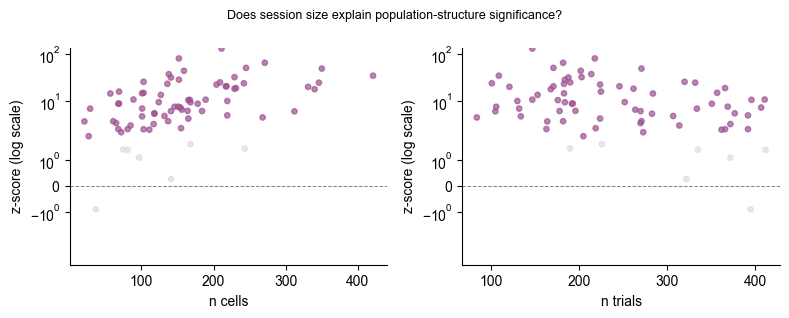

In [5]:
"""
Confound check: is 'significant' just tracking session size (more cells /
more trials trivially giving more statistical power), rather than something
biologically meaningful? If so, subsetting on this criterion would just be
subsetting on session size, not on actual data quality/engagement.
"""
from scipy.stats import spearmanr, mannwhitneyu

r_cells, p_cells = spearmanr(validity_df['n_cells'], validity_df['z'])
r_trials, p_trials = spearmanr(validity_df['n_trials'], validity_df['z'])
print(f'corr(n_cells, z) = {r_cells:.2f} (p={p_cells:.3f})')
print(f'corr(n_trials, z) = {r_trials:.2f} (p={p_trials:.3f})')

sig = validity_df[validity_df['valid_p05']]
nonsig = validity_df[~validity_df['valid_p05']]
if len(nonsig) > 0:
    u, p_mw = mannwhitneyu(sig['n_cells'], nonsig['n_cells'], alternative='two-sided')
    print(f'\nsignificant sessions: median n_cells={sig.n_cells.median():.0f}, '
          f'n_trials={sig.n_trials.median():.0f}')
    print(f'non-significant sessions: median n_cells={nonsig.n_cells.median():.0f}, '
          f'n_trials={nonsig.n_trials.median():.0f}')
    print(f'Mann-Whitney n_cells (significant vs not): p={p_mw:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, col, xlabel in zip(axes, ['n_cells', 'n_trials'], ['n cells', 'n trials']):
    ax.scatter(validity_df[col], validity_df['z'], s=15,
               color=np.where(validity_df['valid_p05'], ANCH_COLOR, NONANCH_COLOR), alpha=0.7)
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z-score (log scale)')
    ax.set_yscale('symlog')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Does session size explain population-structure significance?', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'session_validity_size_confound.pdf'), dpi=200, bbox_inches='tight')
plt.show()


In [6]:
"""
Actionable output: a per-session validity table other notebooks can load to
subset to sessions where a population-wide anchoring state is statistically
supported, rather than picking an arbitrary PC1-explained-variance cutoff.
"""
out_csv = os.path.join(ALL_SESSIONS_DIR, 'session_validity_summary.csv')
validity_df.sort_values(['mouse', 'day']).to_csv(out_csv, index=False)
print(f'Saved -> {out_csv}')
print(f'\ncolumns: {list(validity_df.columns)}')
print(f'\nRecommended default subset: valid_p05 == True '
      f'({validity_df.valid_p05.sum()}/{len(validity_df)} sessions) -- standard significance test.')
print(f'Conservative subset: valid_bonferroni == True '
      f'({validity_df.valid_bonferroni.sum()}/{len(validity_df)} sessions) -- corrected for testing '
      f'all {len(validity_df)} sessions at once, use when false positives are costlier than false negatives.')


Saved -> /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/all_sessions_rasters/session_validity_summary.csv

columns: ['mouse', 'day', 'n_cells', 'n_trials', 'pc1_var', 'null_mean', 'null_std', 'null_95', 'z', 'p', 'excess_over_null95', 'p_parametric', 'valid_p05', 'valid_bonferroni']

Recommended default subset: valid_p05 == True (68/75 sessions) -- standard significance test.
Conservative subset: valid_bonferroni == True (59/75 sessions) -- corrected for testing all 75 sessions at once, use when false positives are costlier than false negatives.


## Summary

**Most sessions show real population-wide structure, but a genuine minority
don't.** 68/75 sessions (91%) clear a standard p<0.05 bar against the
circular-shift null; 59/75 (79%) survive Bonferroni correction for testing
all 75 sessions at once. 7 sessions fail even the uncorrected test outright
(M20D25, M27D21, M27D20, M20D15, M20D24, M22D34, M22D37) -- their real PC1
explained variance is statistically indistinguishable from (M20D25 is even
*below*) what independent per-cell switching would produce by chance given
that session's own cell/trial count.

**The best-vs-worst example makes this concrete, not just statistical.**
M29D23 (z=128.8, PC1=33% vs a null 95th percentile of 28%) shows a clean,
coherent block structure once sorted by PC1 -- most cells anchored for most
of the session, a smooth gradient down to a minority that mostly isn't.
M20D25 (z=-0.9, p=0.80) shows no visible structure at all even after the
same PC1-sorting -- salt-and-pepper noise, exactly matching the "some
sessions just look noisy" observation this notebook was built to
formalize.

**Not simply a session-size artifact.** z correlates modestly with n_cells
(r=0.51, expected -- more cells gives more power to detect a real effect)
but *not* with n_trials (r=-0.34, if anything slightly negative), and
median n_cells doesn't differ significantly between significant and
non-significant sessions (Mann-Whitney p=0.25). Several small sessions
(e.g. n_cells=57-69) still hit very high z-scores, and some larger sessions
(n_cells=141-243) fail to reach significance -- so this isn't just
re-discovering "bigger sessions look more structured."

**A key methodological catch worth flagging**: the first pass reported
0/75 sessions surviving Bonferroni correction, which would have been a
misleading conclusion -- it turned out to be a resolution artifact (the
empirical p-value floors at 1/1001 with 1000 shuffles, which sits *above*
the Bonferroni threshold of 0.00067, even though several sessions have real
z-scores in the hundreds). Fixed by using a parametric normal-approximation
p-value from the z-score for the Bonferroni comparison, which has no such
floor.

**Practical recommendation**: `session_validity_summary.csv` (in
`all_sessions_rasters/`) gives every downstream notebook two ready-made
subsets -- `valid_p05` (68 sessions, standard test, use by default) and
`valid_bonferroni` (59 sessions, conservative, use when a false positive
is more costly than excluding a borderline-real session). For
`population_anchoring_agreement.ipynb`'s cross-region comparisons in
particular, re-running with sessions restricted to `valid_p05 == True`
would be a natural robustness check -- some of the low-session-count
region pairs there (CERE-MEC n=3, HPF-MEC n=4) may include a
non-significant session skewing the pooled estimate.